In [27]:
import pandas as pd
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('s7.csv')

imgs_folder = 'data/mskcc/images'


df.head()

,Unnamed: 0,isic_id,dermoscopic_type,img_l,img_a,img_b,img_ita,tag_id,type,anatomic_site,...,a_3,average_a,b_1,b_2,b_3,average_b,ita_1,ita_2,ita_3,average_ita
0,1,ISIC_6369402,NP-C,66.64,14.82,-5.97,-70.263331,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
1,2,ISIC_6052854,P-C,67.81,13.69,1.41,85.473392,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
2,3,ISIC_7075171,P-NC,64.19,17.55,1.44,84.205466,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
3,4,ISIC_5473699,NP-NC,63.70,18.36,-7.77,-60.440118,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
4,5,ISIC_3868399,P-C,70.05,10.21,1.82,84.813301,105266,normal-skin,upper chest,...,9.0,8.66,12,12.0,11.0,11.66,48,50.0,49.0,49.00


Color in image (LAB):  [np.float64(146.36999999999998) np.float64(140.69) np.float64(129.39)]
Physical color (LAB):  [np.float64(160.64999999999998) np.float64(130.33) np.float64(150.0)]
Correction value (LAB):  [np.float64(1.0975609756097562) np.float64(0.9263629255810648)
 np.float64(1.159285879897983)]


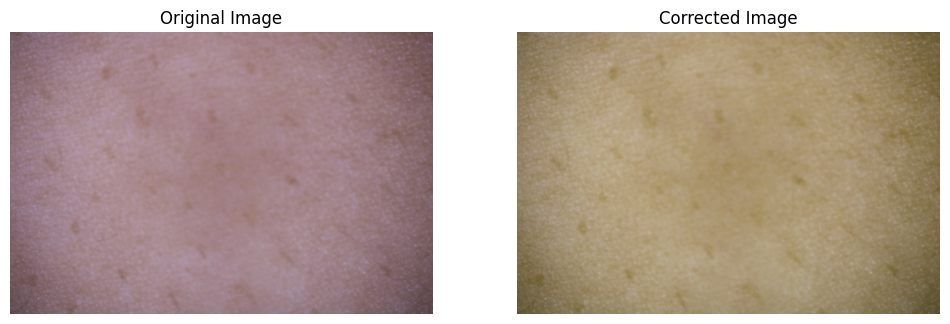

In [ ]:
img_idx = 70

img_name = df.iloc[img_idx]['isic_id'] + '.jpg'
img_path = os.path.join(imgs_folder, img_name)
img = cv.imread(img_path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

color_in_img = df.iloc[img_idx][['img_l', 'img_a', 'img_b']].values
color_physical = df.iloc[img_idx][['average_l', 'average_a', 'average_b']].values

# map to openCV LAB range
color_in_img[0] = color_in_img[0] * (255 / 100)
color_in_img[1] = color_in_img[1] + 128
color_in_img[2] = color_in_img[2] + 128

color_physical[0] = color_physical[0] * (255 / 100)
color_physical[1] = color_physical[1] + 128
color_physical[2] = color_physical[2] + 128

print("Color in image (LAB): ", color_in_img)
print("Physical color (LAB): ", color_physical)

# correction value
correction_value = color_physical / color_in_img
print("Correction value (LAB): ", correction_value)

# Apply correction to the image
img_lab = cv.cvtColor(img, cv.COLOR_RGB2LAB).astype(np.float32)
img_lab[:, :, 0] = img_lab[:, :, 0] * correction_value[0]
img_lab[:, :, 1] = img_lab[:, :, 1] * correction_value[1]
img_lab[:, :, 2] = img_lab[:, :, 2] * correction_value[2]
img_lab = np.clip(img_lab, 0, 255).astype(np.uint8)
img_corrected = cv.cvtColor(img_lab, cv.COLOR_LAB2RGB)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Corrected Image')
plt.imshow(img_corrected)
plt.axis('off')
plt.show()